In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


from chemevo import evolution_V1 as evo

# Chemical Evolution Model, analytic solutions for Oxygen

In [4]:
t = np.linspace(0.0001,14,int(1e3))
m_g = np.ones(len(t))
tau_star = 5
eta = 1
r = 0.4
m_O_cc = 71.3e-4
tau_dep = tau_star / (1 + eta - r)
scale = 1

# For const SFR
Z_O_eq = m_O_cc / (1 + eta - r)
Z_O = Z_O_eq * (1 - np.exp(-t / tau_dep))

# Sanders

In [20]:
def get_Z_X_sanders(g_x):
    tau_x = tau_star/(g_x * m_O_cc)
    m_x_0 = 1e-3
    Z_X_0 = m_x_0 * tau_dep / tau_star * (1 - np.exp(-t/tau_dep))
    Z_X_1 = m_x_0 * tau_dep**2 / (tau_star * tau_x) * (1 - np.exp(-t/tau_dep) - (t/tau_dep) * np.exp(-t/tau_dep))
    Z_X_sanders = Z_X_0 + Z_X_1
    return Z_X_sanders

In [15]:
#Sanders:
g_x = 1000
tau_x = tau_star/(g_x * m_O_cc)


m_x_0 = 1e-3
Z_X_0 = m_x_0 * tau_dep / tau_star * (1 - np.exp(-t/tau_dep))
Z_X_1 = m_x_0 * tau_dep**2 / (tau_star * tau_x) * (1 - np.exp(-t/tau_dep) - (t/tau_dep) * np.exp(-t/tau_dep))
Z_X_sanders = Z_X_0 + Z_X_1

m_X_eq_sanders = m_x_0 * (1 + g_x * Z_O_eq)

# Weinberg

In [31]:
def get_Z_X_weinberg(g_x):
    q = Z_O/Z_O_eq
    m_X_eq_weinberg = m_x_0 * g_x * Z_O_eq
    Z_X_weinberg = Z_O * ( (m_X_eq_weinberg / m_O_cc) * (1 + (1-q)/q * np.log(1-q)) )   
    return Z_X_weinberg


In [ ]:
#Weinberg

q = Z_O/Z_O_eq

m_X_eq_weinberg = m_x_0 * g_x * Z_O_eq

Z_X_weinberg = Z_O * ( (m_X_eq_weinberg / m_O_cc) * (1 + (1-q)/q * np.log(1-q)) )

Text(0, 0.5, 'Z_X')

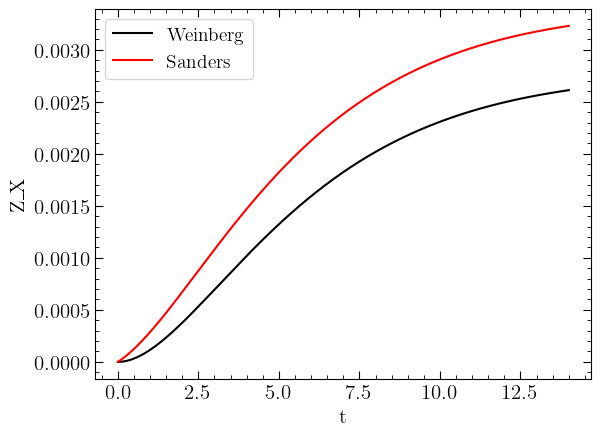

In [19]:
plt.plot(t, Z_X_weinberg, linestyle = '-', color = 'black', label = 'Weinberg')
plt.plot(t, Z_X_sanders, linestyle = '-', color = 'red', label = 'Sanders')
#plt.plot(t, m_X_eq_weinberg/m_g, color = 'orange', linestyle = '--', label = 'eq, Weinberg')
#plt.axhline(m_X_eq_sanders, color = 'gray', linestyle = '-', label = 'eq, Sanders')

plt.legend(loc = 'upper left')

plt.xlabel('t')
plt.ylabel('Z_X')

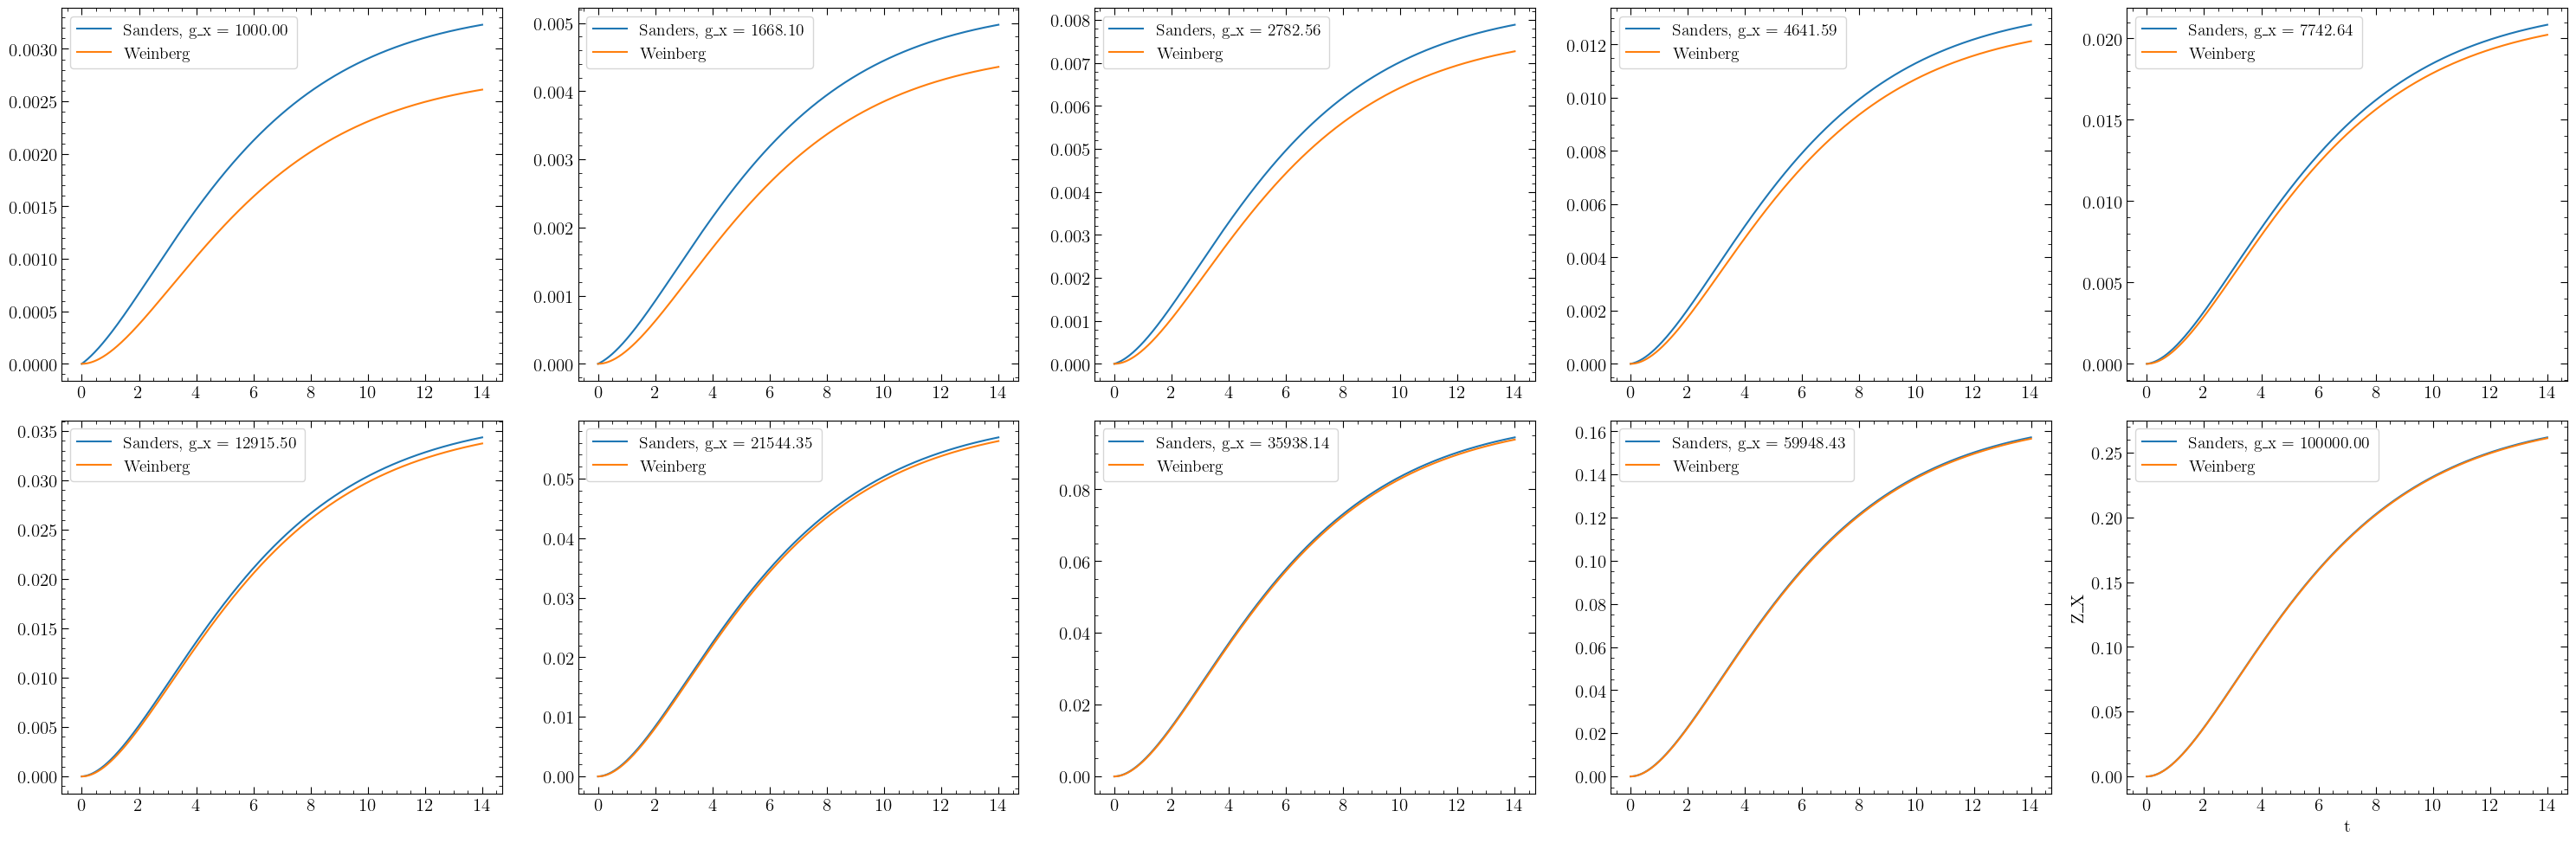

In [40]:
g_xs = np.logspace(3,5,10)
plt.figure(figsize=(30,10))

for i in range(len(g_xs)):
    plt.subplot(2,5,i+1)
    plt.plot(t, get_Z_X_sanders(g_x=g_xs[i]), linestyle = '-', label = f'Sanders, g_x = {g_xs[i]:.2f}')
    plt.plot(t, get_Z_X_weinberg(g_x=g_xs[i]), linestyle = '-', label = f'Weinberg')
    plt.legend(loc = 'upper left')

#plt.legend(loc = 'center left')

plt.xlabel('t')
plt.ylabel('Z_X')
plt.tight_layout()

In [45]:
numerical = evo.Galaxy(t_array=t, m_g_array=m_g, tau_star=tau_star, eta=eta, yields_ref="W2024", alpha_cc_Mn=1, alpha_Ia_Mn=0, g_ratio_Mn=0, g_cc_Mn=1000)

In [54]:
SolarMn = 1.29e-05 #Magg et al. 2022

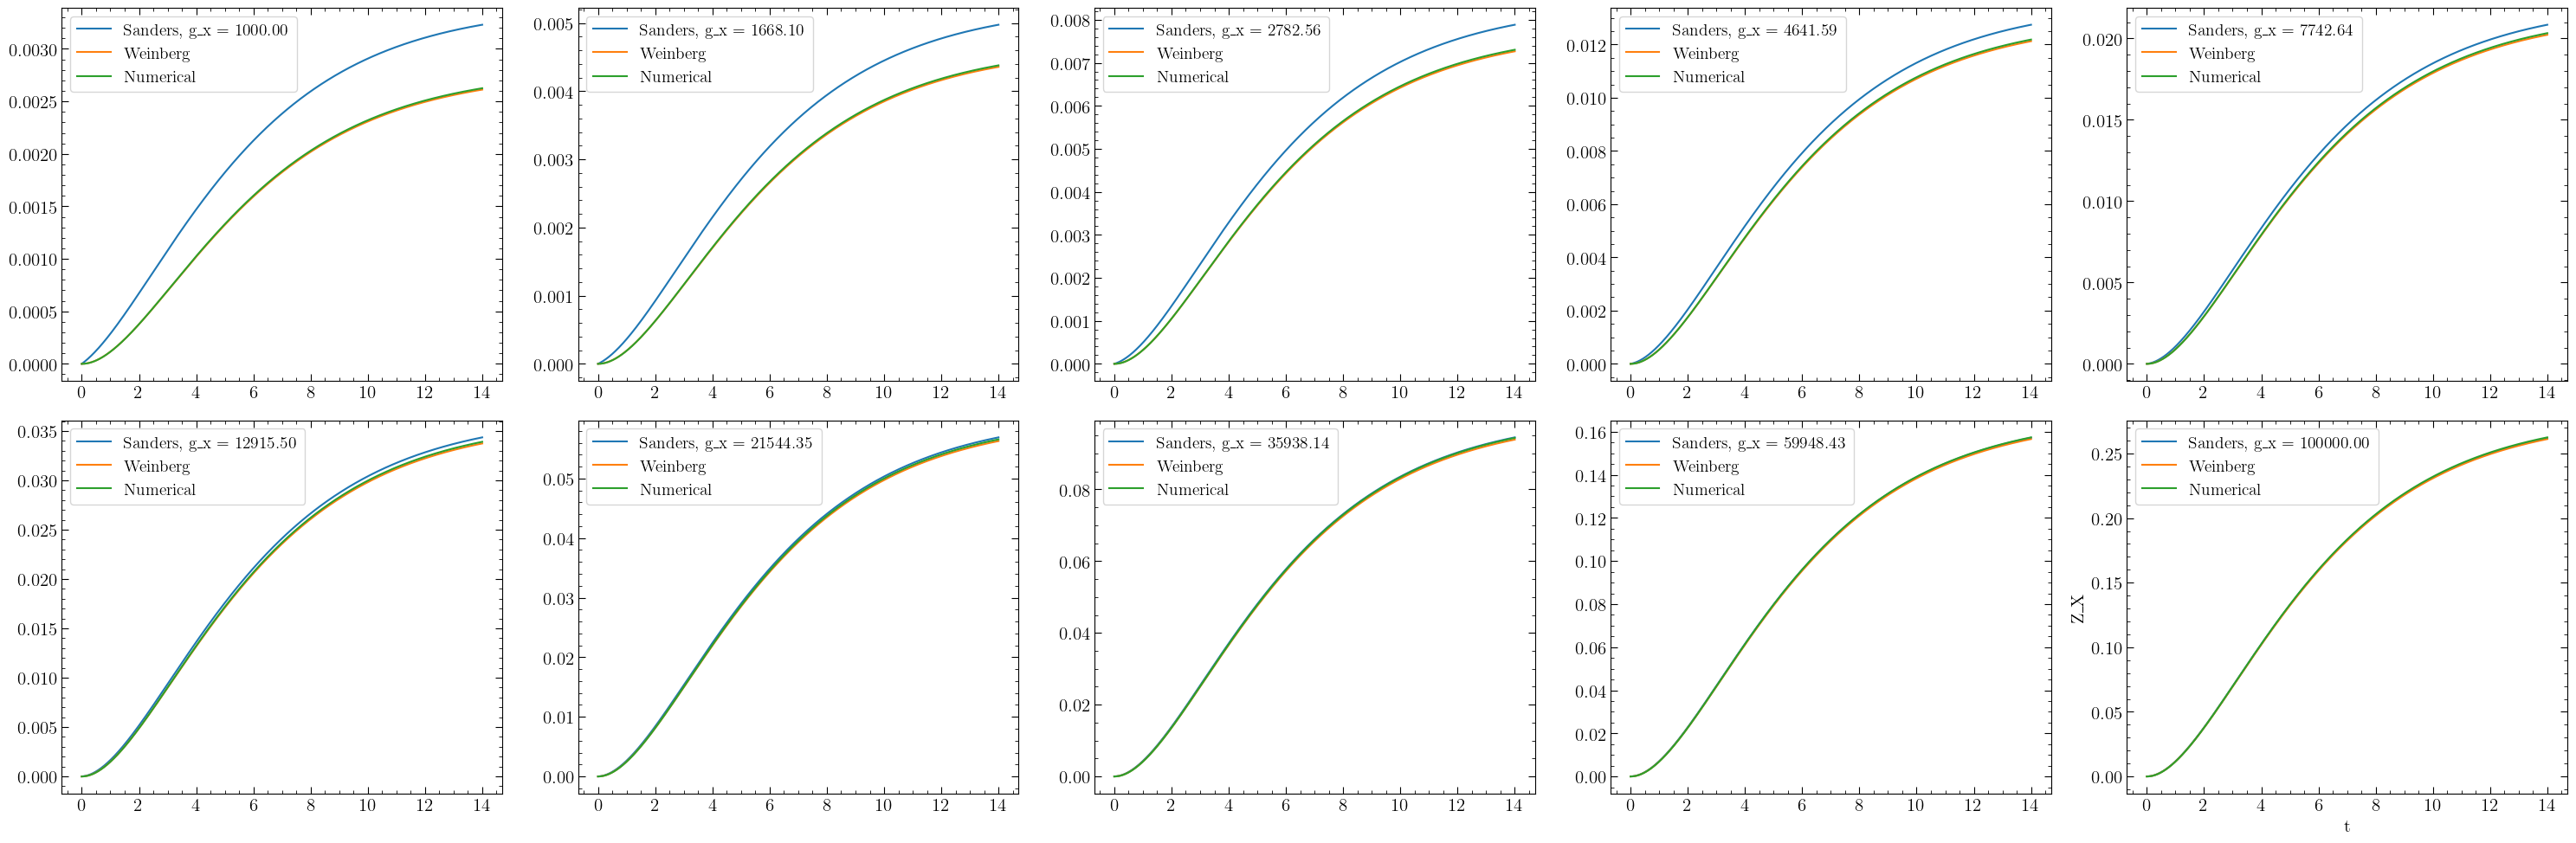

In [58]:
g_xs = np.logspace(3,5,10)
plt.figure(figsize=(30,10))

for i in range(len(g_xs)):
    gal = evo.Galaxy(t_array=t, m_g_array=m_g, tau_star=tau_star, eta=eta, yields_ref="W2024",
                     alpha_cc_Mn=1, alpha_Ia_Mn=0, g_ratio_Mn=0, g_cc_Mn=g_xs[i]/7)
    plt.subplot(2,5,i+1)
    plt.plot(t, get_Z_X_sanders(g_x=g_xs[i]), linestyle = '-', label = f'Sanders, g_x = {g_xs[i]:.2f}')
    plt.plot(t, get_Z_X_weinberg(g_x=g_xs[i]), linestyle = '-', label = f'Weinberg')
    plt.plot(t, gal.compute_z_X(), label = "Numerical")
    plt.legend(loc = 'upper left')

#plt.legend(loc = 'center left')

plt.xlabel('t')
plt.ylabel('Z_X')
plt.tight_layout()